# TF First Neural Network

## Import Libraries

In [8]:
import tensorflow as tf
import numpy as np

print(tf.version.VERSION)

2.20.0


## Dataset

In [9]:
# define some training data (xs as inputs and ys as outputs)

xs = np.array([-1.0,  0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

In [10]:
print(xs, xs.shape)
print(ys, ys.shape)

[-1.  0.  1.  2.  3.  4.] (6,)
[-3. -1.  1.  3.  5.  7.] (6,)


## Define Model (NN Arquitecture)

In [11]:
# define a neural network with one neuron
# for more information on TF functions see: https://www.tensorflow.org/api_docs

model = tf.keras.Sequential([tf.keras.layers.Dense( units=1, input_shape=[1])])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 1)                 2         
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


**Default parameters' inicialization**
- kernel_initializer ('ws') => 'glorot_uniform' (Xavier)
- bias_initializer  ('bs') => 'zeros'

**Viewing initial weights (parameters)**

In [13]:
model.get_weights() # list of parameters

[array([[-1.2176099]], dtype=float32), array([0.], dtype=float32)]

In [14]:
print("wi = ", model.get_weights()[0][0][0])
print("b  = ", model.get_weights()[1][0])

wi =  -1.2176099
b  =  0.0


## Compile Model

In [16]:
# use stochastic gradient descent for optimization and
# the mean squared error loss function

model.compile(optimizer='sgd', loss='mean_squared_error')

In [17]:
model.save('my_first_model_no_training.keras')

In [18]:
print(model.predict([10.0]))

ValueError: Unrecognized data type: x=[10.0] (of type <class 'list'>)

Inspecting Model with [Netron](https://netron.app)

## Training

In [36]:
# fit the model to the data (aka train the model)

history = model.fit(xs, ys, epochs=250)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0038
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0038
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0037
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0036
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0035
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0035
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0034
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0033
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0033
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0032
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0031
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0031
Epoch 13/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0030
Epoch 14/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0029
Epoch 15/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0029
Epoch 16/250
1/1 ━━

Inspect model

In [42]:
print("wi = ", model.get_weights()[0][0][0])
print("b  = ", model.get_weights()[1][0])

wi =  1.9980228
b  =  -0.99387014


In [38]:
# Saving the trained model
model.save('my_first_model_trained.keras')

## Test model

In [50]:
# Predict the output of a new data (Inference)

model.predict(np.array([3,10]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[ 5.000198],
       [18.986359]], dtype=float32)

In [40]:
type(history.history)

dict

In [41]:
history.history.keys()

dict_keys(['loss'])

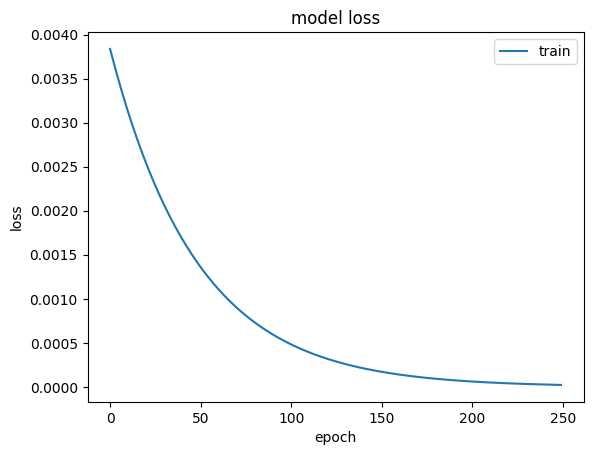

In [43]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper right')
plt.show()